# **Bayesian Project**

# Descripción

- age: Edad del paciente.

- sex: Sexo del paciente.

- cp: Tipo de dolor torácico experimentado.

- trestbps: Presión arterial en reposo al ingreso en el hospital.

- chol: Medición del colesterol sérico.

- fbs: Indicador de si el azúcar en sangre en ayunas es superior a 120 mg/dl.

- restecg: Resultados del electrocardiograma en reposo.

- thalach: Frecuencia cardíaca máxima alcanzada durante la prueba de esfuerzo.

- exang: Presencia de angina inducida por el ejercicio.

- oldpeak: Depresión del segmento ST inducida por el ejercicio relative al reposo.

- slope: La pendiente del segmento ST durante el ejercicio pico.

- ca: Número de vasos principales visibles por fluoroscopia.

- thal: Un tipo de talasemia o resultado de una prueba de esfuerzo con talio.

- num: Diagnóstico de enfermedad cardíaca (variable objetivo).

# Carga e identificación

## Librerías

In [86]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import squarify
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import (accuracy_score, recall_score, f1_score, classification_report, 
                            confusion_matrix, roc_curve, roc_auc_score)
from ucimlrepo import fetch_ucirepo

## Carga del dataset

In [60]:
heart_disease = fetch_ucirepo(id=45) 
df = heart_disease.data.original
  

In [61]:
df.shape

(303, 14)

In [62]:
df.head() 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [63]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object

## Identificando NAs

=== Resumen de valores nulos ===
          Nulos  Porcentaje (%)
age           0            0.00
sex           0            0.00
cp            0            0.00
trestbps      0            0.00
chol          0            0.00
fbs           0            0.00
restecg       0            0.00
thalach       0            0.00
exang         0            0.00
oldpeak       0            0.00
slope         0            0.00
ca            4            1.32
thal          2            0.66
num           0            0.00


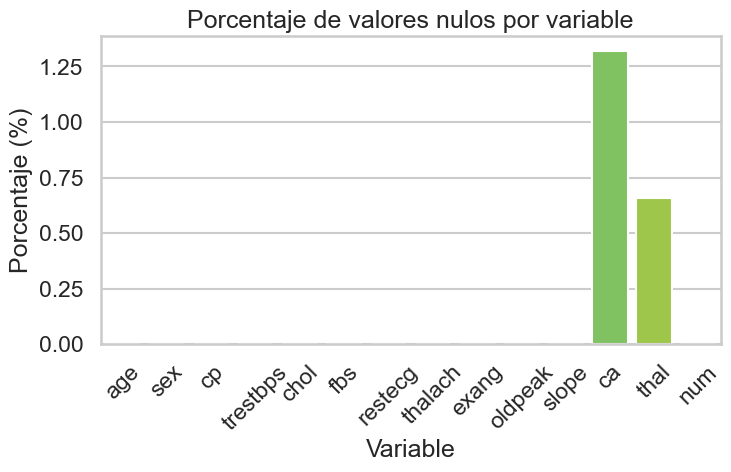

In [64]:
total = len(df)
null_counts = df.isna().sum()
null_percent = (null_counts / total) * 100


missing_summary = pd.DataFrame({
    "Nulos": null_counts,
    "Porcentaje (%)": null_percent.round(2)
})

print("=== Resumen de valores nulos ===")
print(missing_summary)


plt.figure(figsize=(8,4))
sns.barplot(x=missing_summary.index, y=missing_summary["Porcentaje (%)"], hue=missing_summary.index, palette="viridis", legend=False)
plt.title("Porcentaje de valores nulos por variable")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Variable")
plt.xticks(rotation=45)
plt.show()

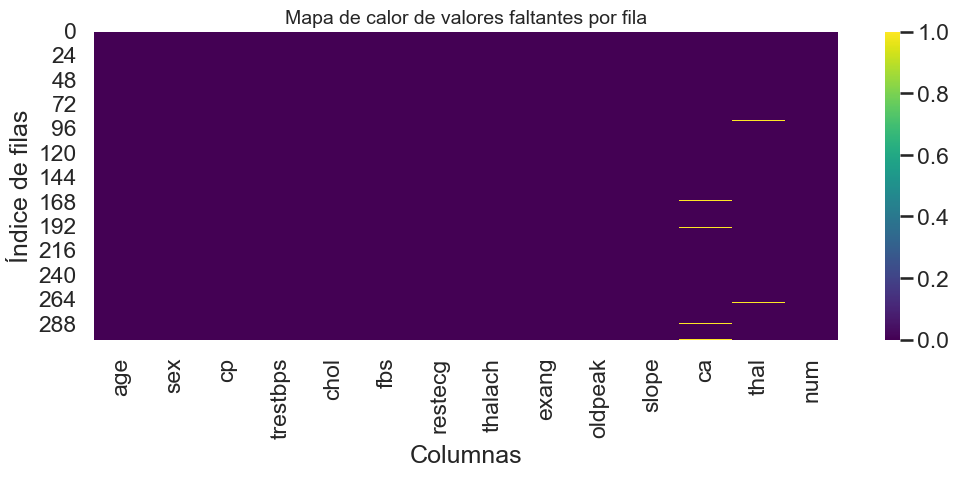

In [65]:
# --- Mapa de calor por filas ---
missing_matrix = df.isnull()
plt.figure(figsize=(12,4))
sns.heatmap(missing_matrix, cmap="viridis", cbar=True, xticklabels=True)
plt.title("Mapa de calor de valores faltantes por fila", fontsize=14)
plt.xlabel("Columnas")
plt.ylabel("Índice de filas")
plt.show()

Nuestro dataset contienemente unicamente valores de NA unicamente en dos variables y con un porcentaje menor al 1.5% así que simplemente imputaremos por moda las filas con valores faltantes pues no introducirá sesgo significativo para nuestro análisis y modelado.

In [66]:
df = df.fillna({
    'ca': df['ca'].mode()[0],
    'thal': df['thal'].mode()[0]
})
print(df.isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


## Estudio de predictores 

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
X = df.drop("num", axis=1)
y = df["num"]

selector = SelectKBest(score_func=mutual_info_classif, k=6)
X_new = selector.fit_transform(X, y)

# Ver qué variables quedaron
selected_features = X.columns[selector.get_support()]
print(selected_features)


Index(['cp', 'exang', 'oldpeak', 'slope', 'ca', 'thal'], dtype='object')


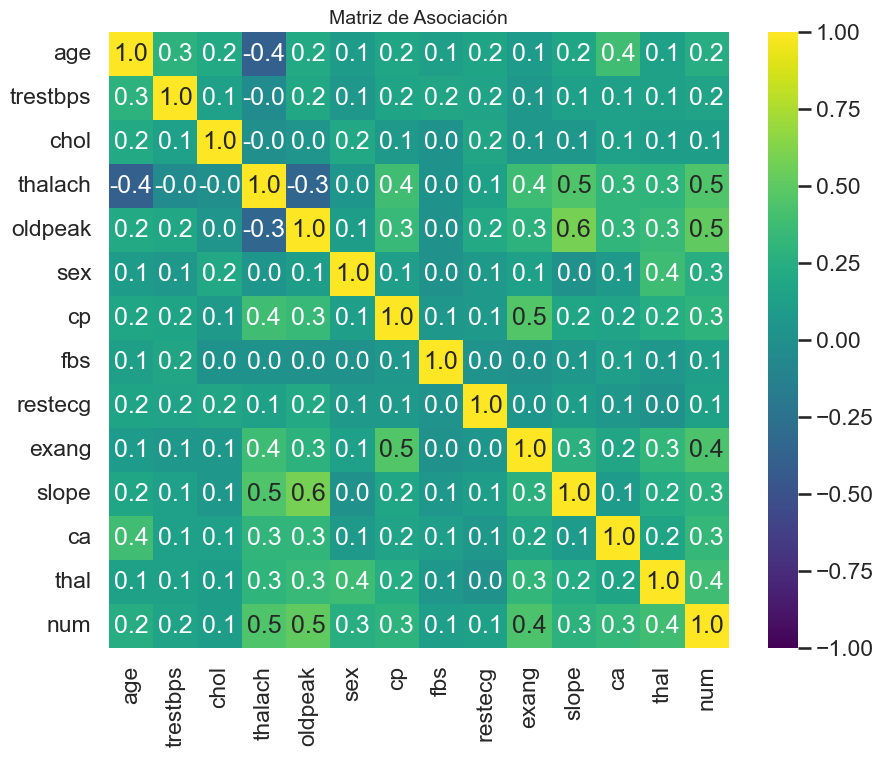

In [68]:
# ---- Funciones auxiliares ----
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

def correlation_ratio(categories, values):
    fcat, _ = pd.factorize(categories)
    values = np.array(values)
    cat_num = np.max(fcat) + 1
    y_avg = np.mean(values)
    
    numerator = sum([
        len(values[fcat == i]) * (np.mean(values[fcat == i]) - y_avg)**2
        for i in range(cat_num)
    ])
    denominator = np.sum((values - y_avg)**2)
    
    return np.sqrt(numerator/denominator) if denominator != 0 else 0


# ---- Definir variables ----
num_vars = ["age","trestbps","chol","thalach","oldpeak"]
cat_vars = ["sex","cp","fbs","restecg","exang","slope","ca","thal","num"]

# ---- Matriz de asociación ----
cols = num_vars + cat_vars
assoc_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for i in cols:
    for j in cols:
        if i == j:
            assoc_matrix.loc[i, j] = 1.0
        elif (i in num_vars) and (j in num_vars):
            assoc_matrix.loc[i, j] = np.corrcoef(df[i], df[j])[0,1]
        elif (i in cat_vars) and (j in cat_vars):
            assoc_matrix.loc[i, j] = cramers_v(df[i], df[j])
        else:
            num_col = i if i in num_vars else j
            cat_col = j if i in num_vars else i
            assoc_matrix.loc[i, j] = correlation_ratio(df[cat_col], df[num_col])

# ---- Heatmap ----
plt.figure(figsize=(10,8))
sns.heatmap(
    assoc_matrix.astype(float),
    annot=True,
    fmt=".1f",  
    cmap="viridis",
    vmin=-1, vmax=1, center=0
)
plt.title("Matriz de Asociación", fontsize=14)
plt.show()

En base a nuestro estudio de de predictores  tenemos una primer aproximación de los vairalbes más influyentes en nuestra variable objetivo, por lo que hemos decidido usar las varibles: 'sex', 'exang', 'cp', 'oldpeak' y además 'age', 'cho' para la realización del EDA

# **EDA**

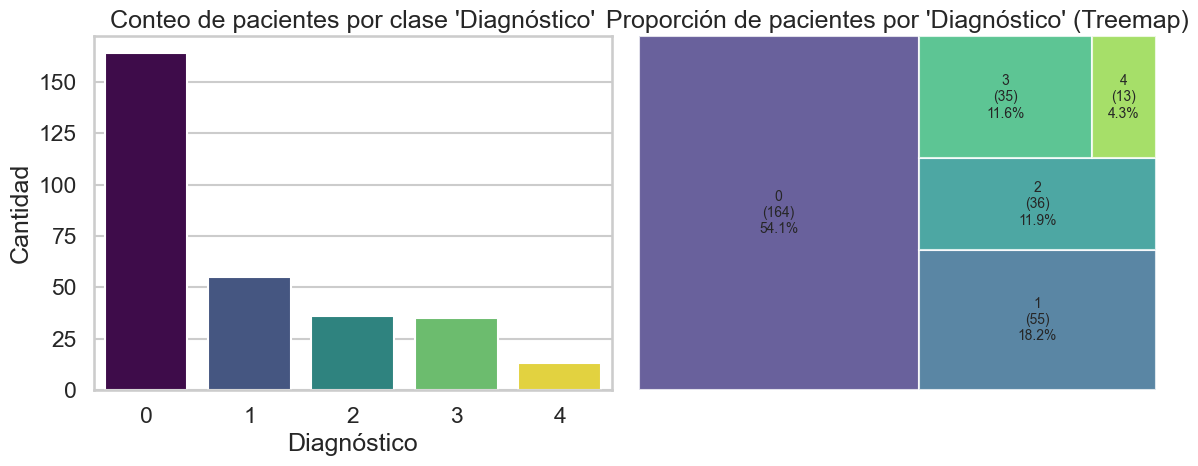

<Figure size 640x480 with 0 Axes>

In [69]:
df = df.rename(columns={'num': 'target'})
num_counts = df['target'].value_counts()
num_labels = num_counts.index

plt.figure(figsize=(12,5))

# 1️⃣ Countplot
plt.subplot(1,2,1)
sns.countplot(x='target', data=df, hue='target', palette='viridis', legend=False)
plt.title("Conteo de pacientes por clase 'Diagnóstico'")
plt.xlabel("Diagnóstico")
plt.ylabel("Cantidad")

# 2️⃣ Treemap
plt.subplot(1,2,2)
# Crear etiquetas que incluyan el nombre de la clase y el porcentaje
total = sum(num_counts)
labels = [f'{label}\n({count})\n{count/total:.1%}' for label, count in num_counts.items()]
colors = sns.color_palette('viridis', len(num_counts))

squarify.plot(sizes=num_counts.values, 
              label=labels, 
              color=colors,
              alpha=0.8,
              text_kwargs={'fontsize':10})

plt.title("Proporción de pacientes por 'Diagnóstico' (Treemap)")
plt.axis('off') # Ocultar los ejes

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

Observamos que más del 50% de nuestra población se encuentra sana y no padece de cardiopatía. Solo el 4.3% (al rededor de 12) de las personas padecen de cardiopatía grave. Y casi el 20% se encuentra con cardiopatía con el nivel más bajo de gravedad, este es el tipo de cardiopatía más frecuente entre las personas de nuetro estudio.

Debido a la baja proporción de personas diagnosticadas con cardiopatía, agruparemos las clases '1', '2', '3', y '4'.
Nuestra variable objetivo cuenta con 5 categorías:
- 0 si está sana
- 1, 2, 3 y 4 indican la gravedad de la cardiopatía (Entre más alto más grave).

Simplificaremos dicha variable para indicar:

- 0 si está sana
- 1 si padece cardiopatía

In [70]:
df['target'] = df['target'].apply(lambda x: 0 if x == 0 else 1)

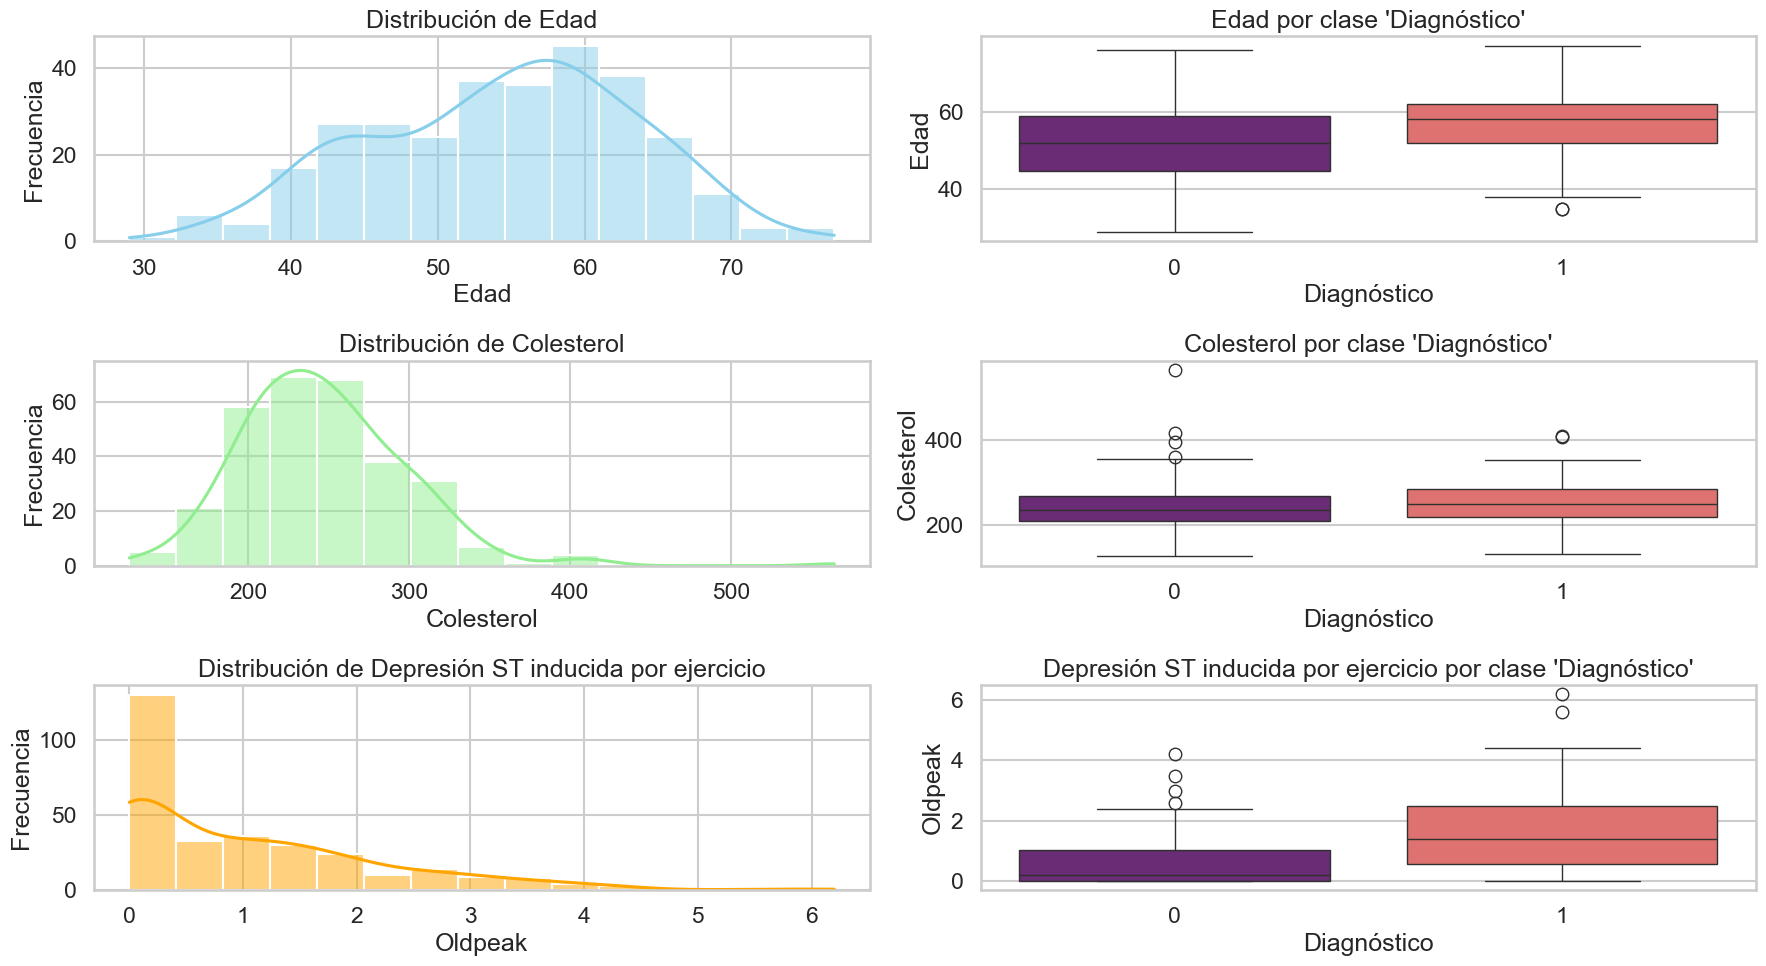

In [71]:
fig, axes = plt.subplots(3, 2, figsize=(18,10))

# =========================
# BLOQUE 1: Age
# =========================
sns.histplot(df['age'], bins=15, kde=True, color='skyblue', ax=axes[0,0])
axes[0,0].set_title("Distribución de Edad")
axes[0,0].set_xlabel("Edad")
axes[0,0].set_ylabel("Frecuencia")

sns.boxplot(x='target', y='age', data=df, hue='target', palette='magma', ax=axes[0,1], legend=False)
axes[0,1].set_title("Edad por clase 'Diagnóstico'")
axes[0,1].set_xlabel("Diagnóstico")
axes[0,1].set_ylabel("Edad")

# =========================
# BLOQUE 2: Cholesterol
# =========================
sns.histplot(df['chol'], bins=15, kde=True, color='lightgreen', ax=axes[1,0])
axes[1,0].set_title("Distribución de Colesterol")
axes[1,0].set_xlabel("Colesterol")
axes[1,0].set_ylabel("Frecuencia")

sns.boxplot(x='target', y='chol', data=df, hue='target', palette='magma', ax=axes[1,1], legend=False)
axes[1,1].set_title("Colesterol por clase 'Diagnóstico'")
axes[1,1].set_xlabel("Diagnóstico")
axes[1,1].set_ylabel("Colesterol")

# Gráfico 3: Oldpeak
sns.histplot(df['oldpeak'], bins=15, kde=True, color='orange', ax=axes[2,0])
axes[2,0].set_title("Distribución de Depresión ST inducida por ejercicio")
axes[2,0].set_xlabel("Oldpeak")
axes[2,0].set_ylabel("Frecuencia")

sns.boxplot(x='target', y='oldpeak', data=df, hue='target', palette='magma', ax=axes[2,1], legend=False)
axes[2,1].set_title("Depresión ST inducida por ejercicio por clase 'Diagnóstico'")
axes[2,1].set_xlabel("Diagnóstico")
axes[2,1].set_ylabel("Oldpeak")

plt.tight_layout()
plt.show()



- Age: Nuestra población de edad se encuentra concentrada mayormente entre los 50 y 65 años aproximadamente, siento las edades que tienden por la izquierda a 60 con mayor representación. Además encontramos que para las personas diagnosticadas con cardiopatía suelen tener más de 40 años, pero esto puede ser por la poca representación de personas menores de 40 años en el estudio
- Colesterol: Para el colesterol tenemos los valores concentrados aproximadamente entre 100 y 350 aproximadamente, contando con raras ocasiones donde una persona tiene el colesterol por más de 350. Además, para las personas que padecen cardiopatía la mitad de estas personas tiene ligeramente mayores niveles de coesterol, aunque no hay grande variabilidad entre las personas que padecen colesterol y las que no.
- Oldpeak: 
Observamos que la depresión del segmento ST inducida por el ejercicio en relación con el reposo, tiene un sesgo hacía la derecha. Siento la moda de este valor entre 0 y 0.3. Además, para las personas que padecen cardiopatía son más probables a tener mayor depresión en el segmento ST inducida por el ejercicio respecto al reposo.

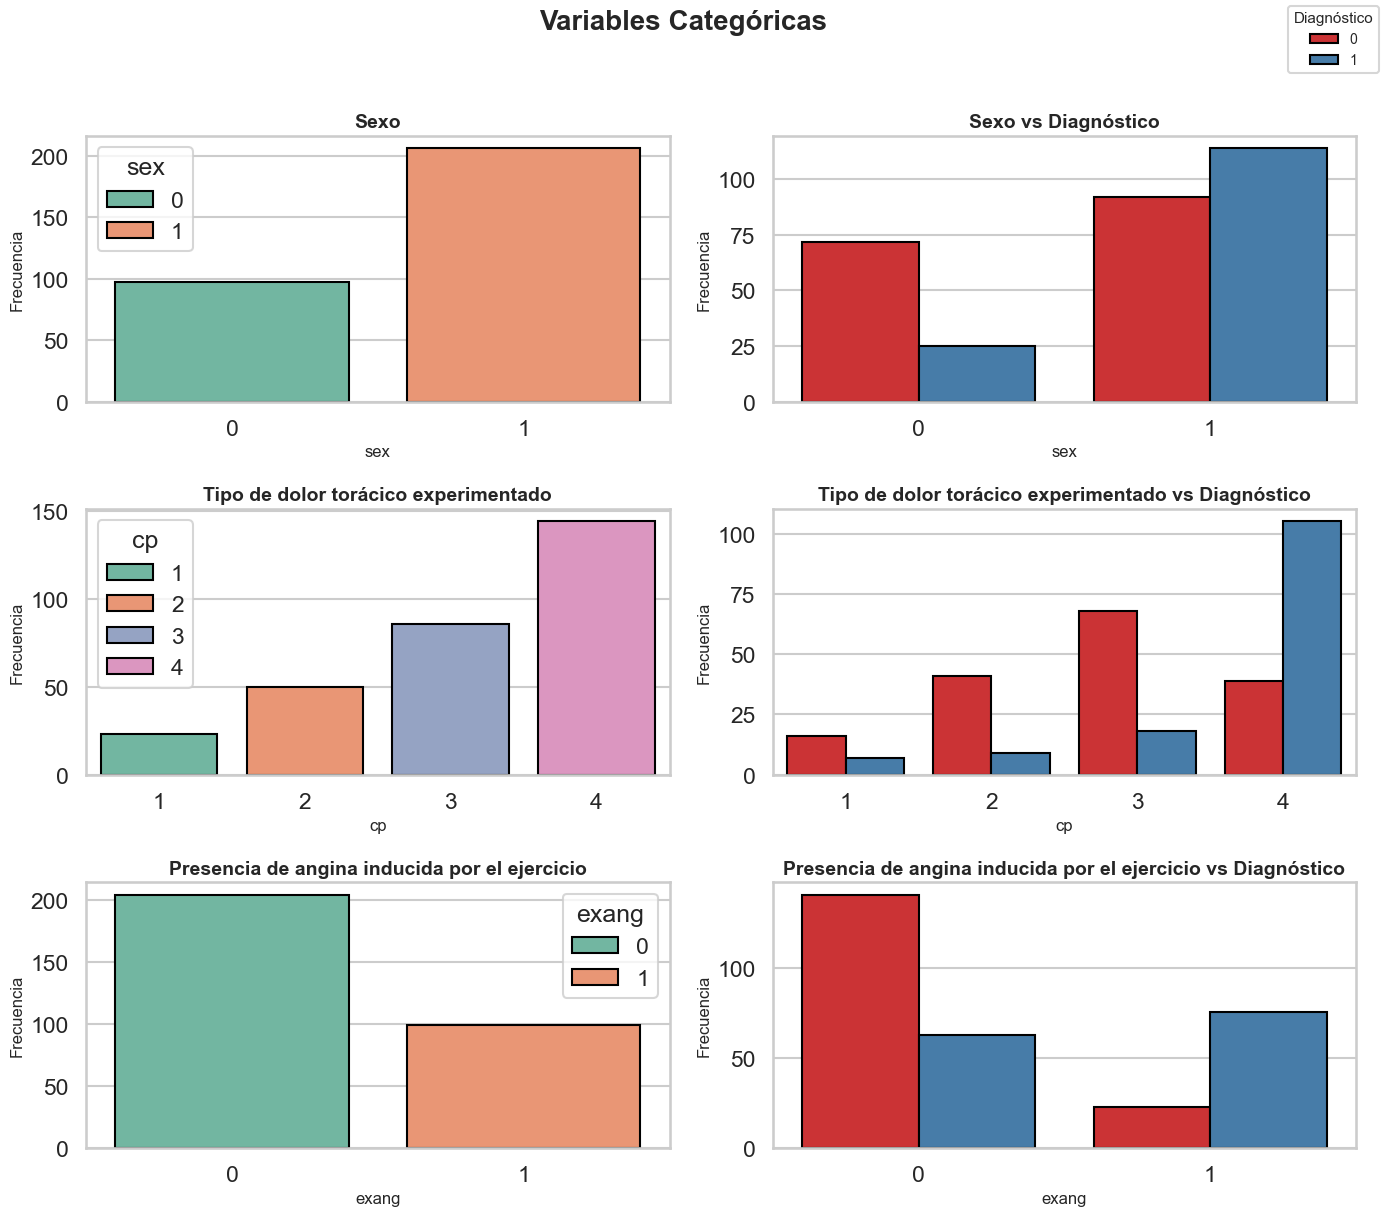

In [ ]:
categorical_vars = ['sex', 'cp', 'exang']

descriptions = {
    'sex': "Sexo",
    'cp': "Tipo de dolor torácico experimentado",
    'exang': "Presencia de angina inducida por el ejercicio",
}

sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(len(categorical_vars), 2, figsize=(14, 12))
fig.suptitle("Variables Categóricas", fontsize=20, fontweight="bold", y=1.02)

# Variable para guardar handles y labels de la primera vez
legend_handles, legend_labels = None, None

for i, var in enumerate(categorical_vars):
    # Distribución simple (columna izquierda)
    sns.countplot(
        data=df, x=var, ax=axes[i,0], hue = var, palette="Set2", edgecolor="black"
    )
    axes[i,0].set_title(f"{descriptions.get(var, var)}", fontsize=14, fontweight="bold")
    axes[i,0].set_xlabel(var, fontsize=12)
    axes[i,0].set_ylabel("Frecuencia", fontsize=12)

    # Relación con target (columna derecha)
    ax = sns.countplot(
        data=df, x=var, hue='target', ax=axes[i,1], palette="Set1", edgecolor="black"
    )
    axes[i,1].set_title(f"{descriptions.get(var, var)} vs Diagnóstico", fontsize=14, fontweight="bold")
    axes[i,1].set_xlabel(var, fontsize=12)
    axes[i,1].set_ylabel("Frecuencia", fontsize=12)

    # Guardar handles y labels de la primera vez
    if legend_handles is None and legend_labels is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # Eliminar leyenda local
    ax.legend_.remove()

# Crear leyenda global usando los handles capturados
fig.legend(legend_handles, legend_labels, title="Diagnóstico", loc="upper right", fontsize=10, title_fontsize=11, frameon=True)

plt.tight_layout()
plt.show()


- Sex: Observamos que dentro del estudio existe el doble de mujeres que de hombres. Además que es más probable que una mujer padezca cardiopatía, pero esto puede ser sesgado por la diferencia en la clase mayoritaria de las mujeres.
- Tipo de dolor toracico (cp): El tipo de dolor toracico más experimentado es el tipo 4 y a su vez las personas, que padecen de este dolor con mayor frecuencia padecen cardiopatía tambien. Mientras que para los otros tipo de dolores, es menos probable que padezcan cardiopatia en base a este dolor.
- Presencia de angina inducida por ejercicio (Exang): En nuestra muestra existe el doble de personas que no tuvieran presencia de angina durante el ejercicio. Además, podemos notar que si una persona tiene la presencia de esta angina durante el ejercicio es más probable que padezca de cardiopatía.

# **Preprocesamiento**

In [73]:
categorical_vars = ['cp', 'exang', 'slope', 'thal', 'ca']
numeric_vars = ['oldpeak', 'age', 'trestbps', 'chol', 'thalach']
target = "target"

X = df[categorical_vars + numeric_vars]
y = df[target]

# División en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [74]:
# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_vars),
        ("num", StandardScaler(), numeric_vars)
    ]
)

# **Modelo**

In [75]:
pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', GaussianNB())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8852459016393442

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61


Matriz de confusión:
 [[27  6]
 [ 1 27]]


In [76]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')

print("=== Validación cruzada ===")
print("Accuracy promedio:", cv_scores.mean().round(3))
print("Desviación estándar:", cv_scores.std().round(3))

=== Validación cruzada ===
Accuracy promedio: 0.828
Desviación estándar: 0.025


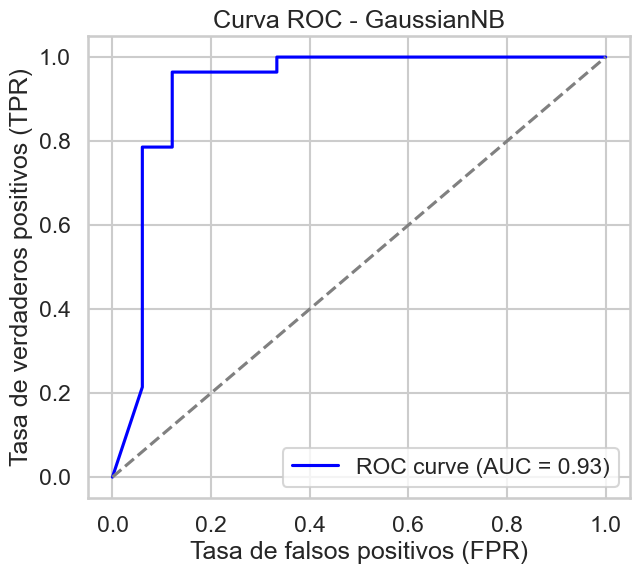

In [77]:
# Probabilidades de predicción en test
y_proba = pipeline.predict_proba(X_test)[:, 1]  # solo la clase positiva
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - GaussianNB')
plt.legend(loc="lower right")
plt.show()

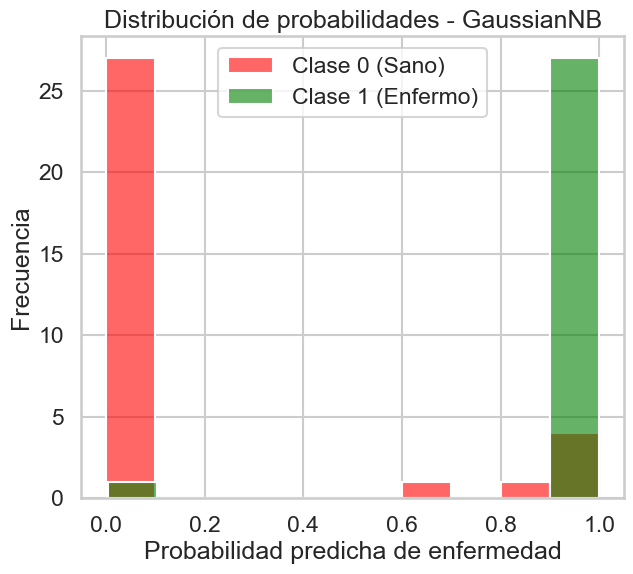

In [78]:
# Distribución de probabilidades predichas
plt.figure(figsize=(7, 6))
sns.histplot(y_proba[y_test == 0], bins=10, color='red', alpha=0.6, label='Clase 0 (Sano)')
sns.histplot(y_proba[y_test == 1], bins=10, color='green', alpha=0.6, label='Clase 1 (Enfermo)')
plt.xlabel("Probabilidad predicha de enfermedad")
plt.ylabel("Frecuencia")
plt.title("Distribución de probabilidades - GaussianNB")
plt.legend()
plt.show()

# **Comparación con BernoulliNB y Logistic Regression**

## Pipelines

--- Tabla Comparativa de Nuevos Clasificadores ---


,Model,Accuracy,Recall,F1-Score,AUC
0,Logistic Regression,0.918033,0.964286,0.915254,0.971861
1,Bernoulli Naive Bayes,0.901639,0.964286,0.900000,0.977273


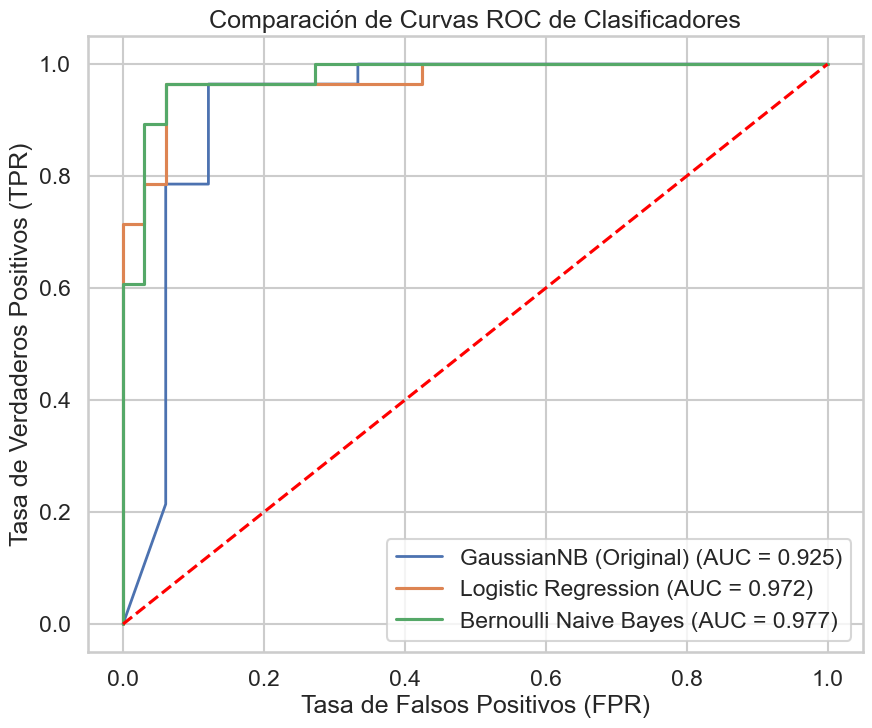

In [ ]:
# Preprocesadores
preprocessor_bnb = ColumnTransformer(
    transformers=[
        # Las categóricas se convierten a 0/1 con OneHotEncoder
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_vars),
        # Las numéricas se agrupan (discretizan) y luego se convierten a 0/1
        ("num", KBinsDiscretizer(n_bins=4, encode='onehot-dense', strategy='uniform'), numeric_vars)
    ])

# 3. Definición de los nuevos pipelines
pipeline_lr = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

pipeline_bnb = Pipeline(steps=[
    ('preprocessing', preprocessor_bnb), # Usa el preprocesador para datos binarios
    ('classifier', BernoulliNB())
])

# Diccionario con los nuevos modelos a entrenar
new_models = {
    "Logistic Regression": pipeline_lr,
    "Bernoulli Naive Bayes": pipeline_bnb
}

# 4. Entrenar y evaluar los nuevos modelos
results_list = []
for model_name, model_pipeline in new_models.items():
    # Entrenar
    model_pipeline.fit(X_train, y_train)
    # Evaluar
    y_pred = model_pipeline.predict(X_test)
    y_proba_model = model_pipeline.predict_proba(X_test)[:, 1]
    
    # Almacenar métricas clave
    results_list.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba_model)
    })

# Mostrar tabla comparativa de los nuevos modelos
results_df = pd.DataFrame(results_list)
print("--- Tabla Comparativa de Nuevos Clasificadores ---")
display(results_df)

# Gráfico ROC Comparativo (incluyendo el GaussianNB original)
plt.figure(figsize=(10, 8))

# --- Curva del GaussianNB original  ---
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_proba) 
auc_gnb = roc_auc_score(y_test, y_proba)
plt.plot(fpr_gnb, tpr_gnb, label=f'GaussianNB (Original) (AUC = {auc_gnb:.3f})', lw=2)

# --- Curvas de los nuevos modelos ---
for model_name, model_pipeline in new_models.items():
    y_proba_model = model_pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba_model)
    auc = roc_auc_score(y_test, y_proba_model)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')

# --- Formato del gráfico ---
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # Línea de referencia
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Comparación de Curvas ROC de Clasificadores')
plt.legend()
plt.grid(True)
plt.show()

# **Análisis y reporte**

In [ ]:
# Extraemos el clasificador y el preprocesador del pipeline ya entrenado
gnb_classifier = pipeline.named_steps['classifier']
gnb_preprocessor = pipeline.named_steps['preprocessing']

# Obtenemos los nombres de las características numéricas
num_features_list = numeric_vars 

# Obtenemos los nombres de todas las características despues de la transformación
transformed_feature_names = gnb_preprocessor.get_feature_names_out()

# Creamos un slice (rango) para identificar dónde están las columnas numéricas en el array de datos transformados.
# El método 'get_feature_names_out' prefija los nombres con 'num__' y 'cat__'.
num_slice = [i for i, col in enumerate(transformed_feature_names) if col.startswith('num__')]

# Ahora usamos ese slice para extraer las medias correctas de `theta_`
means_sano = gnb_classifier.theta_[0][num_slice]
means_enfermo = gnb_classifier.theta_[1][num_slice]

# Verificamos que las longitudes ahora coincidan
assert len(num_features_list) == len(means_sano) == len(means_enfermo)

# Creamos el DataFrame para visualizar las medias por clase
means_df = pd.DataFrame({
    'Feature': num_features_list,
    'Mean_Sano (Clase 0)': means_sano,
    'Mean_Enfermo (Clase 1)': means_enfermo
})

means_df['Mean_Difference'] = np.abs(means_df['Mean_Sano (Clase 0)'] - means_df['Mean_Enfermo (Clase 1)'])
means_df = means_df.sort_values(by='Mean_Difference', ascending=False)

print("Relevancia de variables numéricas en Gaussian Naive Bayes (basado en la diferencia de medias)")
means_df

Relevancia de variables numéricas en Gaussian Naive Bayes (basado en la diferencia de medias)
    Feature  Mean_Sano (Clase 0)  Mean_Enfermo (Clase 1)  Mean_Difference
4   thalach             0.376924               -0.444838         0.821761
0   oldpeak            -0.360977                0.426018         0.786994
1       age            -0.192996                0.227770         0.420767
2  trestbps            -0.125267                0.147837         0.273104
3      chol            -0.071054                0.083857         0.154912


### **Dumbell Plot de Variables relevantes**

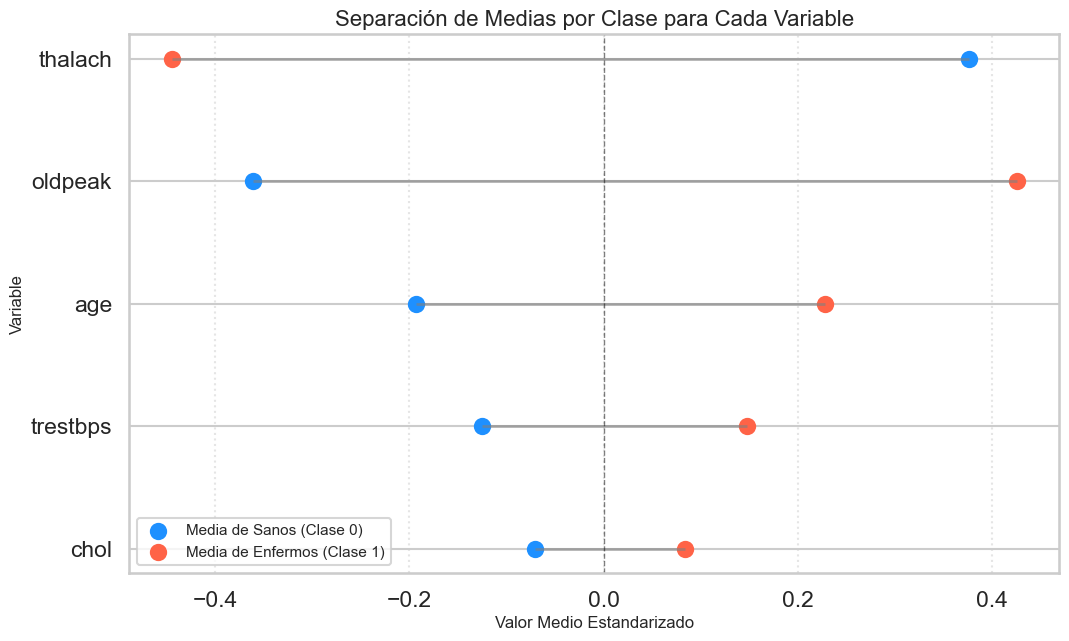

In [85]:
# --- (Dumbbell Plot) ---

fig, ax = plt.subplots(figsize=(12, 7))

# Crear las líneas que conectan los puntos ("dumbbells")
ax.hlines(y=means_df['Feature'], 
          xmin=means_df['Mean_Sano (Clase 0)'], 
          xmax=means_df['Mean_Enfermo (Clase 1)'], 
          color='grey', alpha=0.6, lw=2)

# Crear los puntos para cada clase
ax.scatter(means_df['Mean_Sano (Clase 0)'], means_df['Feature'], 
           color='dodgerblue', s=120, label='Media de Sanos (Clase 0)')
ax.scatter(means_df['Mean_Enfermo (Clase 1)'], means_df['Feature'], 
           color='tomato', s=120, label='Media de Enfermos (Clase 1)')

# Línea de referencia en cero (la media general después de estandarizar)
ax.axvline(0, color='black', linestyle='--', lw=1, alpha=0.5)

# Títulos y etiquetas
ax.set_title('Separación de Medias por Clase para Cada Variable', fontsize=16)
ax.set_xlabel('Valor Medio Estandarizado', fontsize=12)
ax.set_ylabel('Variable', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='x', linestyle=':', alpha=0.5)

# Invertir el eje Y para que la variable más importante quede arriba
ax.invert_yaxis() 
plt.show()

## Ranking de Relevancia Predictiva: Gaussian Naive Bayes

### Variables Críticas

**1. `thalach` (Freq. Cardíaca Máxima) - Mean_Diff: 0.82**
- Sanos: +0.37 (capacidad superior) vs Enfermos: -0.44 (capacidad reducida)
- Reserva cardíaca como biomarcador primario

**2. `oldpeak` (Depresión ST) - Mean_Diff: 0.78**
- Sanos: -0.36 (respuesta normal) vs Enfermos: +0.42 (isquemia evidente)
- Anomalías electrocardiográficas bajo esfuerzo

### Variables Secundarias

**3. `age` (Edad) - Mean_Diff: 0.42**
- Gradiente etario predecible: jóvenes sanos (-0.19) vs mayores enfermos (+0.22)

### Variables Débiles

**4-5. `trestbps`/`chol` (Presión/Colesterol) - Mean_Diff: 0.15**
- Separación marginal entre clases
- **Observación crítica:** Factores de riesgo tradicionales menos predictivos que respuesta al ejercicio

### Insight Clínico Clave

El modelo prioriza **métricas de rendimiento dinámico** (thalach, oldpeak) sobre **factores de riesgo estáticos** (presión, colesterol). Sugiere que la **capacidad funcional** del corazón es más diagnósticamente informativa que parámetros basales.

> **Implicación:** Para screening cardíaco, las pruebas de esfuerzo aportan más valor predictivo que paneles lipídicos rutinarios.

### **Análisis del modelo Logistico**

In [87]:
# Código para analizar la relevancia en LogisticRegression
# Extraemos el clasificador y el preprocesador
lr_classifier = pipeline_lr.named_steps['classifier']
lr_preprocessor = pipeline_lr.named_steps['preprocessing']

# Obtenemos TODOS los nombres de las características después de la transformación
feature_names = lr_preprocessor.get_feature_names_out()

# Creamos un DataFrame de coeficientes
coeffs_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_classifier.coef_[0]
})
coeffs_df['Abs_Coefficient'] = np.abs(coeffs_df['Coefficient'])
coeffs_df = coeffs_df.sort_values(by='Abs_Coefficient', ascending=False)

print("\nRelevancia de variables en Regresión Logística (basado en coeficientes)")
print(coeffs_df.head(10))


Relevancia de variables en Regresión Logística (basado en coeficientes)
          Feature  Coefficient  Abs_Coefficient
12    cat__ca_0.0    -1.450069         1.450069
11  cat__thal_7.0     1.008484         1.008484
3       cat__cp_4     1.005580         1.005580
9   cat__thal_3.0    -0.758058         0.758058
15    cat__ca_3.0     0.649955         0.649955
2       cat__cp_3    -0.580726         0.580726
7    cat__slope_2     0.570794         0.570794
14    cat__ca_2.0     0.504466         0.504466
13    cat__ca_1.0     0.476347         0.476347
0       cat__cp_1    -0.389864         0.389864


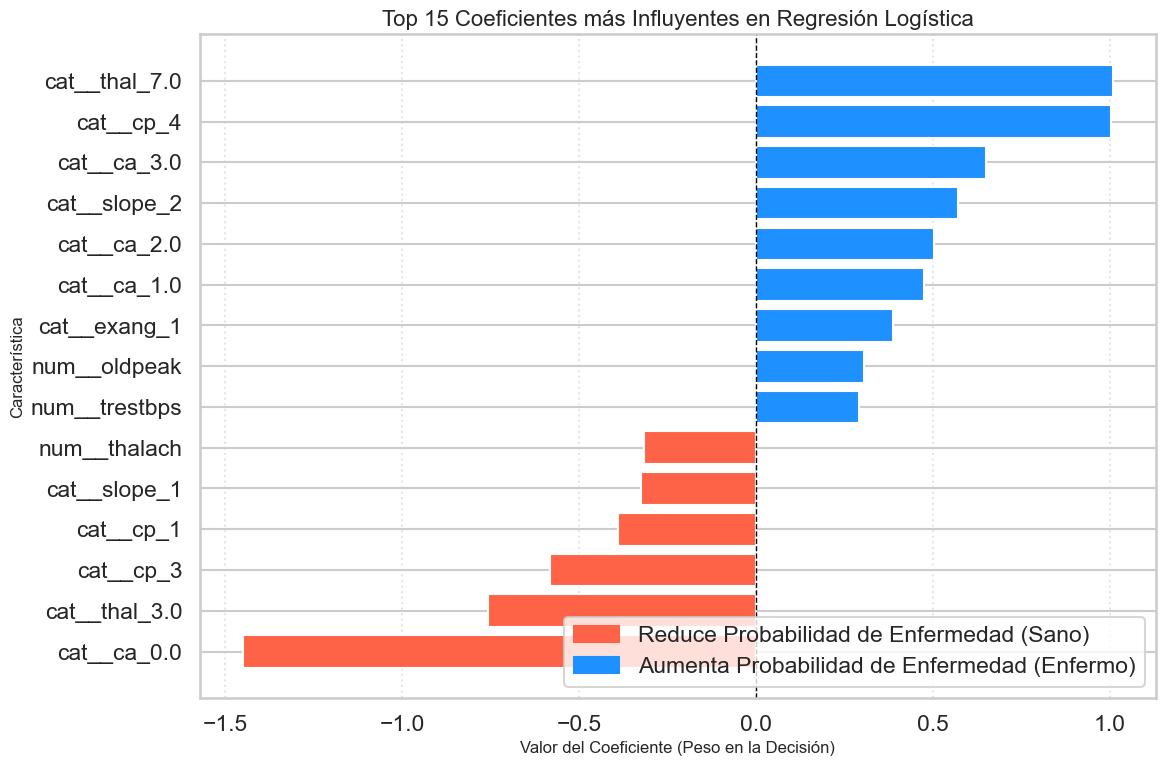

In [89]:
# --- Visualizar Coeficientes de Regresión Logística ---

top_coeffs = coeffs_df.head(15).sort_values(by='Coefficient', ascending=True)
colors = ['tomato' if c < 0 else 'dodgerblue' for c in top_coeffs['Coefficient']]

# Crear el gráfico de barras horizontales
plt.figure(figsize=(12, 8))
plt.barh(top_coeffs['Feature'], top_coeffs['Coefficient'], color=colors)
plt.axvline(0, color='black', linestyle='--', lw=1)

# Títulos y etiquetas
plt.title('Top 15 Coeficientes más Influyentes en Regresión Logística', fontsize=16)
plt.xlabel('Valor del Coeficiente (Peso en la Decisión)', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.5)

# Añadir una leyenda manual para los colores
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='tomato', label='Reduce Probabilidad de Enfermedad (Sano)')
blue_patch = mpatches.Patch(color='dodgerblue', label='Aumenta Probabilidad de Enfermedad (Enfermo)')
plt.legend(handles=[red_patch, blue_patch], loc='lower right')

plt.tight_layout()
plt.show()

### **Análisis de Coeficientes: Regresión Logística**


### Top Predictores por Magnitud

**Protectores Potentes (Coef. Negativo):**
- `cat__ca_0.0` (-1.45): **Cero vasos obstruidos** = indicador más fuerte de salud cardíaca
- `cat__thal_3.0` (-0.75): Perfusión normal en prueba talio
- `cat__cp_3` (-0.58): Dolor torácico atípico (menos preocupante que tipo 4)

**Factores de Riesgo Críticos (Coef. Positivo):**
- `cat__thal_7.0` (+1.00): **Defecto reversible** en perfusión miocárdica
- `cat__cp_4` (+1.00): Dolor asintomático con hallazgos anórmales
- `cat__slope_2` (+0.57): Respuesta ST plana al ejercicio

### Contraste Metodológico

**Logística vs Naive Bayes:**
- **Logística:** Prioriza **categorías diagnósticas específicas** (ca, thal, cp)
- **Naive Bayes:** Enfocado en **métricas de rendimiento continuas** (thalach, oldpeak)


El modelo logístico revela jerarquía diagnóstica realista: **obstrucción coronaria** (ca) como gold standard, seguido de **pruebas de perfusión** (thal) y **manifestaciones clínicas** (cp).

# **Conclusiones**


**Fortalezas de Bayes operacionales:**
- Simplicidad computacional + robustez predictiva
- **Recall (96%)**: Minimiza falsos negativos críticos

**Limitación teórica fundamental:**
- Supuesto de independencia entre variables médicas **irreal**. En medicina, es poco realista asumir que métricas como oldpeak (depresión ST) y thalach (frecuencia cardíaca) son completamente independientes.

### Convergencia Interpretativa

**Naive Bayes:** Prioriza **respuesta fisiológica al esfuerzo** (thalach, oldpeak)
**Regresión Logística:** Enfatiza **hallazgos diagnósticos categóricos** (ca, thal, cp)

Ambos modelos identifican **mismos factores clave** por rutas diferentes.

### Aplicabilidad Médica

**Limitaciones éticas:** Herramienta de **apoyo**, nunca sustituto del criterio clínico

> El Modelo bayesiano ofrece **valor clínico inmediato** como sistema de alerta temprana, balanceando simplicidad operacional con performance diagnóstica robusta.